# Import Toolekit

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [7]:
df = pd.read_csv("../assets/heart-disease-classification-logistic-regression/heart_disease_data.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.shape

(303, 14)

# Preprocessing

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)
print("duplicates removed")

duplicates removed


In [11]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
for col in df.columns:
    print(f"{col} has {df[col].nunique()} unique values")

age has 41 unique values
sex has 2 unique values
cp has 4 unique values
trestbps has 49 unique values
chol has 152 unique values
fbs has 2 unique values
restecg has 3 unique values
thalach has 91 unique values
exang has 2 unique values
oldpeak has 40 unique values
slope has 3 unique values
ca has 5 unique values
thal has 4 unique values
target has 2 unique values


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [14]:
df.describe().T[["mean", "50%", "std"]]

,mean,50%,std
age,54.420530,55.5,9.047970
sex,0.682119,1.0,0.466426
cp,0.963576,1.0,1.032044
trestbps,131.602649,130.0,17.563394
chol,246.500000,240.5,51.753489
fbs,0.149007,0.0,0.356686
restecg,0.526490,1.0,0.526027
thalach,149.569536,152.5,22.903527
exang,0.327815,0.0,0.470196
oldpeak,1.043046,0.8,1.161452


# Cross-Validation

In [15]:
x = df.drop("target", axis=1)
y = df["target"]

In [16]:
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [17]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

x_train.shape, y_train.shape

((241, 13), (241,))

In [19]:
scaler = StandardScaler()

num_feats  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_feats = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
x_train[num_feats] = scaler.fit_transform(x_train[num_feats])
x_test[num_feats] = scaler.transform(x_test[num_feats])

x_train.head()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
59,0.289062,0,0,-0.192086,1.222784,0,0,0.405122,0,-0.889676,2,1,2
247,1.267182,1,1,1.590543,0.035438,0,1,-1.364273,1,-0.889676,1,3,1
289,0.071702,0,0,-0.192086,-0.818618,0,2,-0.910582,1,0.771788,1,1,3
288,0.289062,1,0,-1.194814,1.889363,0,1,-0.320784,1,1.602520,1,1,3
64,0.397742,1,2,0.476400,-0.693634,1,0,0.677336,0,-0.889676,2,0,2


In [20]:
model = LogisticRegression()
model.fit(x_train, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
x_train_pred = model.predict(x_train)
train_acc = accuracy_score(y_train, x_train_pred)
print(f"Train accuracy: {train_acc:.2f}")

Train accuracy: 0.85


In [22]:
x_test_pred = model.predict(x_test)
test_acc = accuracy_score(y_test, x_test_pred)
print(f"Test accuracy: {test_acc:.2f}")

Test accuracy: 0.79


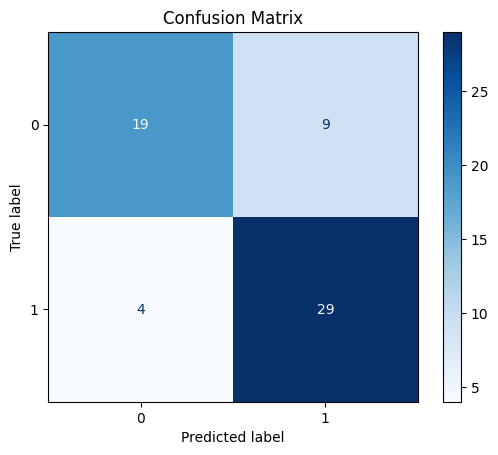

In [24]:
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

# Saving the model 

In [ ]:
joblib.dump(model, "logistic-regression-model.pkl")


['logistic-regression-model.pkl']

# Pipeline

In [ ]:
scaler = StandardScaler()
num_feats  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_feats = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, num_feats),
    ],
    remainder="passthrough"
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

